ANALISIS EXPLORATORIO PARA  KC_HOUSE_DATA

In [6]:
import pandas as pd

df = pd.read_csv('/content/kc_house_data.csv')
display(df.head())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Este dataset, `kc_house_data.csv`, contiene información sobre viviendas vendidas en el condado de King, Estados Unidos, entre mayo de 2014 y mayo de 2015. El objetivo principal de este dataset es facilitar el análisis y la construcción de modelos predictivos para el precio de las viviendas.

Algunas de las columnas clave incluyen:
*   **id**: Un identificador único para cada vivienda.
*   **date**: La fecha de venta de la vivienda.
*   **price**: El precio de venta de la vivienda (la variable objetivo).
*   **bedrooms**: Número de dormitorios.
*   **bathrooms**: Número de baños.
*   **sqft_living**: Superficie habitable en pies cuadrados.
*   **sqft_lot**: Superficie del lote en pies cuadrados.
*   **floors**: Número de pisos.
*   **waterfront**: Si la propiedad tiene vistas al mar (0 = no, 1 = sí).
*   **view**: Una calificación de 0 a 4 sobre la calidad de la vista.
*   **condition**: Una calificación de 1 a 5 sobre la condición de la vivienda.
*   **grade**: Una calificación del sistema de calificación de viviendas del condado de King, de 1 a 13.
*   **sqft_above**: Superficie habitable por encima del nivel del suelo.
*   **sqft_basement**: Superficie habitable del sótano.
*   **yr_built**: Año de construcción.
*   **yr_renovated**: Año de la última renovación.
*   **zipcode**: Código postal.
*   **lat**, **long**: Coordenadas de latitud y longitud.
*   **sqft_living15**, **sqft_lot15**: Superficie de la vivienda y del lote para los 15 vecinos más cercanos en 2015 (útil para el contexto del vecindario).

Este dataset es ideal para tareas de regresión, donde se busca predecir el `price` basándose en las características de la vivienda.

In [7]:
num_filas, num_columnas = df.shape
print(f"El dataset tiene {num_filas} filas y {num_columnas} columnas.")

El dataset tiene 21613 filas y 21 columnas.


In [8]:
total_nulos = df.isnull().sum().sum()
print(f"El dataset tiene un total de {total_nulos} valores nulos.")

El dataset tiene un total de 0 valores nulos.


In [9]:
print("\nTipos de datos de las columnas:")
display(df.info())


Tipos de datos de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21

None

## Preparación de Datos

In [10]:
# Convertir la columna 'date' a tipo datetime
df['date'] = pd.to_datetime(df['date'])
print("La columna 'date' ha sido convertida a tipo datetime.")
display(df.head())

La columna 'date' ha sido convertida a tipo datetime.


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 1. Estadísticas Descriptivas

### Variables Numéricas

In [11]:
# Estadísticas descriptivas para variables numéricas
# Excluir 'id' y 'zipcode' de estas estadísticas generales si no son representativas como números continuos
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Algunas columnas numéricas son en realidad categóricas o identificadores
# Ajustamos la lista de columnas numéricas para el describe
exclude_from_describe = ['id', 'zipcode'] # 'zipcode' y 'id' no se interpretan como valores continuos

descriptive_numeric_cols = [col for col in numeric_cols if col not in exclude_from_describe]

print("Estadísticas descriptivas de las variables numéricas clave:")
display(df[descriptive_numeric_cols].describe().T)

Estadísticas descriptivas de las variables numéricas clave:


,count,mean,std,min,25%,50%,75%,max
price,21613.0,540088.141767,367127.196483,75000.0000,321950.000,450000.0000,645000.000,7.700000e+06
bedrooms,21613.0,3.370842,0.930062,0.0000,3.000,3.0000,4.000,3.300000e+01
bathrooms,21613.0,2.114757,0.770163,0.0000,1.750,2.2500,2.500,8.000000e+00
sqft_living,21613.0,2079.899736,918.440897,290.0000,1427.000,1910.0000,2550.000,1.354000e+04
sqft_lot,21613.0,15106.967566,41420.511515,520.0000,5040.000,7618.0000,10688.000,1.651359e+06
floors,21613.0,1.494309,0.539989,1.0000,1.000,1.5000,2.000,3.500000e+00
waterfront,21613.0,0.007542,0.086517,0.0000,0.000,0.0000,0.000,1.000000e+00
view,21613.0,0.234303,0.766318,0.0000,0.000,0.0000,0.000,4.000000e+00
condition,21613.0,3.409430,0.650743,1.0000,3.000,3.0000,4.000,5.000000e+00
grade,21613.0,7.656873,1.175459,1.0000,7.000,7.0000,8.000,1.300000e+01


### Variables Categóricas (y Pseudo-Categóricas)

In [12]:
# Identificar variables que se comportan como categóricas (por ejemplo, con pocos valores únicos o rangos)
categorical_like_cols = ['bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition', 'grade', 'zipcode']

print("Estadísticas para variables categóricas (o pseudo-categóricas):")
for col in categorical_like_cols:
    print(f"\n--- Columna: {col} ---")
    print(f"Cantidad de categorías únicas: {df[col].nunique()}")
    display(df[col].value_counts().head(10)) # Mostrar las 10 categorías más frecuentes

Estadísticas para variables categóricas (o pseudo-categóricas):

--- Columna: bedrooms ---
Cantidad de categorías únicas: 13


,count
bedrooms,
3,9824
4,6882
2,2760
5,1601
6,272
1,199
7,38
0,13
8,13



--- Columna: bathrooms ---
Cantidad de categorías únicas: 30


,count
bathrooms,
2.50,5380
1.00,3852
1.75,3048
2.25,2047
2.00,1930
1.50,1446
2.75,1185
3.00,753
3.50,731



--- Columna: floors ---
Cantidad de categorías únicas: 6


...

,count
condition,
3,14031
4,5679
5,1701
2,172
1,30



--- Columna: grade ---
Cantidad de categorías únicas: 12


,count
grade,
7,8981
8,6068
9,2615
6,2038
10,1134
11,399
5,242
12,90
4,29



--- Columna: zipcode ---
Cantidad de categorías únicas: 70


,count
zipcode,
98103,602
98038,590
98115,583
98052,574
98117,553
98042,548
98034,545
98118,508
98023,499


## 2. Detección de Anomalías

### Duplicados

In [13]:
# Detección de filas duplicadas exactas
duplicados_completos = df.duplicated().sum()
print(f"Número de filas duplicadas exactas: {duplicados_completos}")

# Detección de duplicados por 'id' (si 'id' debería ser único)
duplicados_por_id = df.duplicated(subset=['id']).sum()
print(f"Número de IDs duplicados: {duplicados_por_id}")

# Si hay IDs duplicados, se podrían mostrar:
if duplicados_por_id > 0:
    print("IDs duplicados:")
    display(df[df.duplicated(subset=['id'], keep=False)].sort_values(by='id').head())

Número de filas duplicadas exactas: 0
Número de IDs duplicados: 177
IDs duplicados:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2496,1000102,2014-09-16,280000.0,6,3.00,2400,9373,2.0,0,0,...,7,2400,0,1991,0,98002,47.3262,-122.214,2060,7316
2497,1000102,2015-04-22,300000.0,6,3.00,2400,9373,2.0,0,0,...,7,2400,0,1991,0,98002,47.3262,-122.214,2060,7316
16814,7200179,2014-10-16,150000.0,2,1.00,840,12750,1.0,0,0,...,6,840,0,1925,0,98055,47.4840,-122.211,1480,6969
16815,7200179,2015-04-24,175000.0,2,1.00,840,12750,1.0,0,0,...,6,840,0,1925,0,98055,47.4840,-122.211,1480,6969
11433,109200390,2014-08-20,245000.0,3,1.75,1480,3900,1.0,0,0,...,7,1480,0,1980,0,98023,47.2977,-122.367,1830,6956


### Valores Atípicos (Outliers) - Uso de Diagramas de Caja

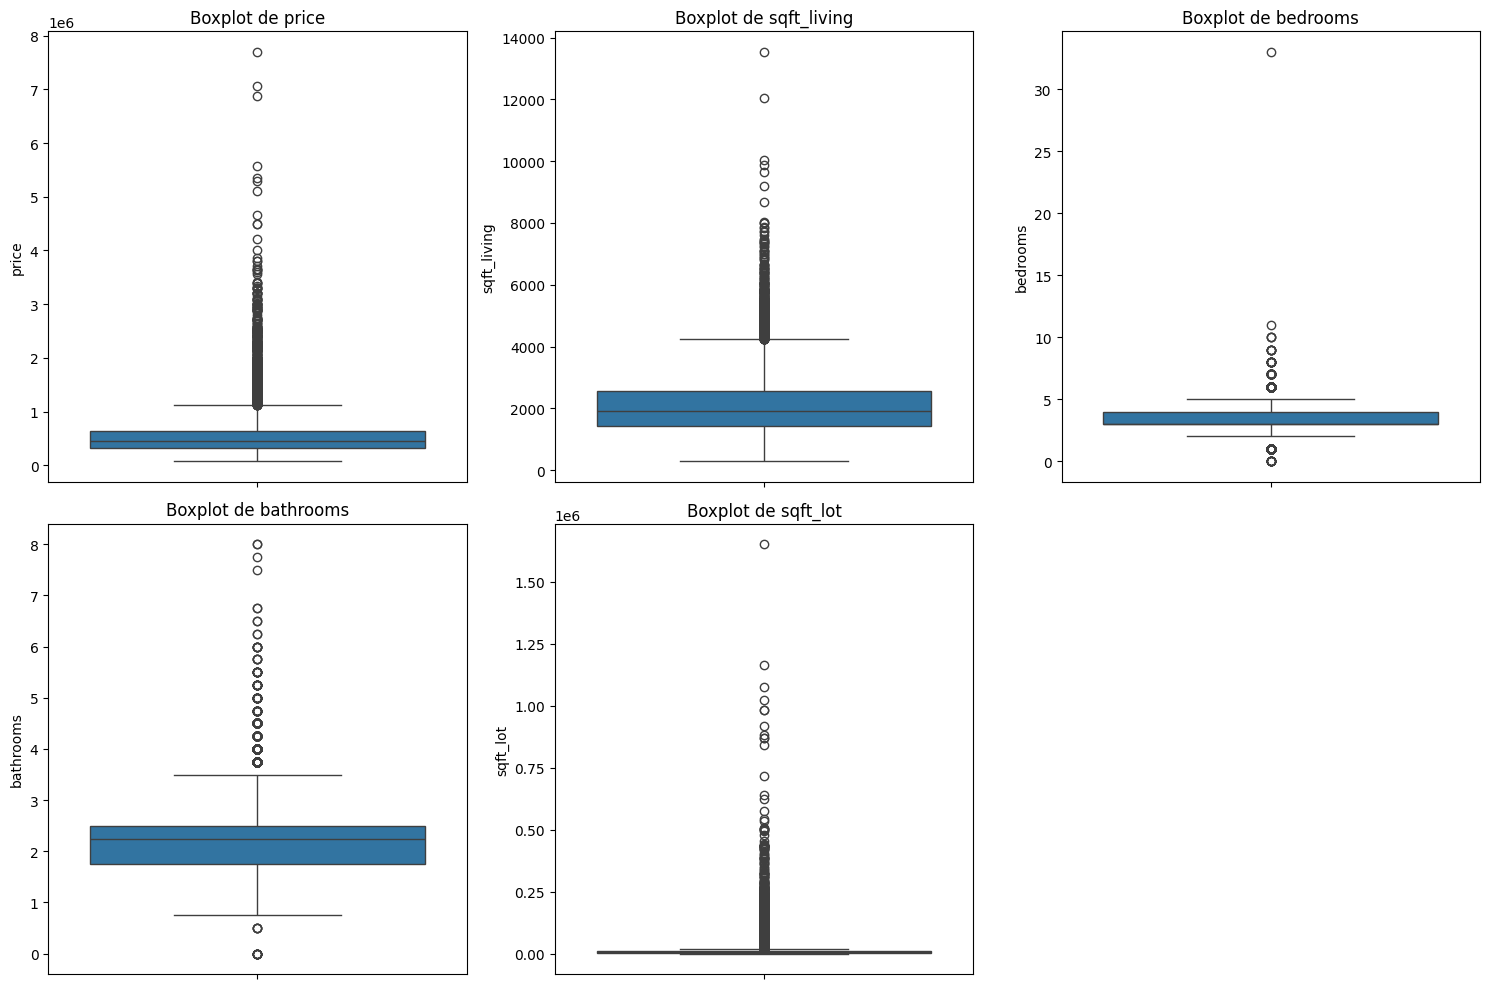

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar algunas columnas numéricas clave para detectar outliers
outlier_cols = ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'sqft_lot']

plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_cols):
    plt.subplot(2, 3, i + 1) # Ajustar la cuadrícula según la cantidad de columnas
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

## 3. Relación entre Variables

### Matriz de Correlación entre Variables Numéricas

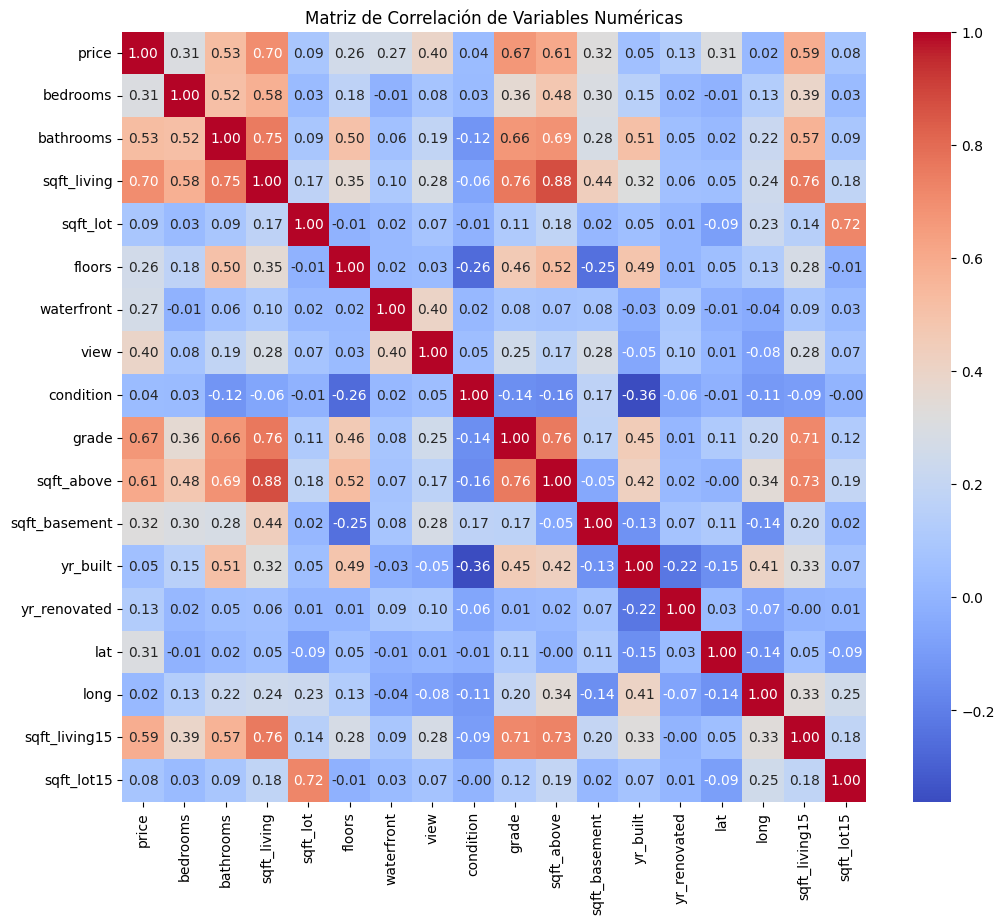

In [15]:
# Calcular la matriz de correlación para variables numéricas
# Excluir 'id' y 'zipcode' ya que no son medidas de correlación significativas en este contexto
numeric_for_corr = df[descriptive_numeric_cols]
correlation_matrix = numeric_for_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Tablas de Contingencia (Ejemplo para variables categóricas)

In [16]:
# Ejemplo de tabla de contingencia entre 'waterfront' y 'view'
# Esto es útil para ver la distribución conjunta de dos variables categóricas.
if 'waterfront' in df.columns and 'view' in df.columns:
    print("Tabla de contingencia entre 'waterfront' y 'view':")
    contingency_table = pd.crosstab(df['waterfront'], df['view'])
    display(contingency_table)
else:
    print("Las columnas 'waterfront' o 'view' no están presentes para generar la tabla de contingencia.")

Tabla de contingencia entre 'waterfront' y 'view':


view,0,1,2,3,4
waterfront,,,,,
0,19489,331,955,491,184
1,0,1,8,19,135


## 4. Visualizaciones Gráficas

### Histogramas para Distribución de Variables Numéricas

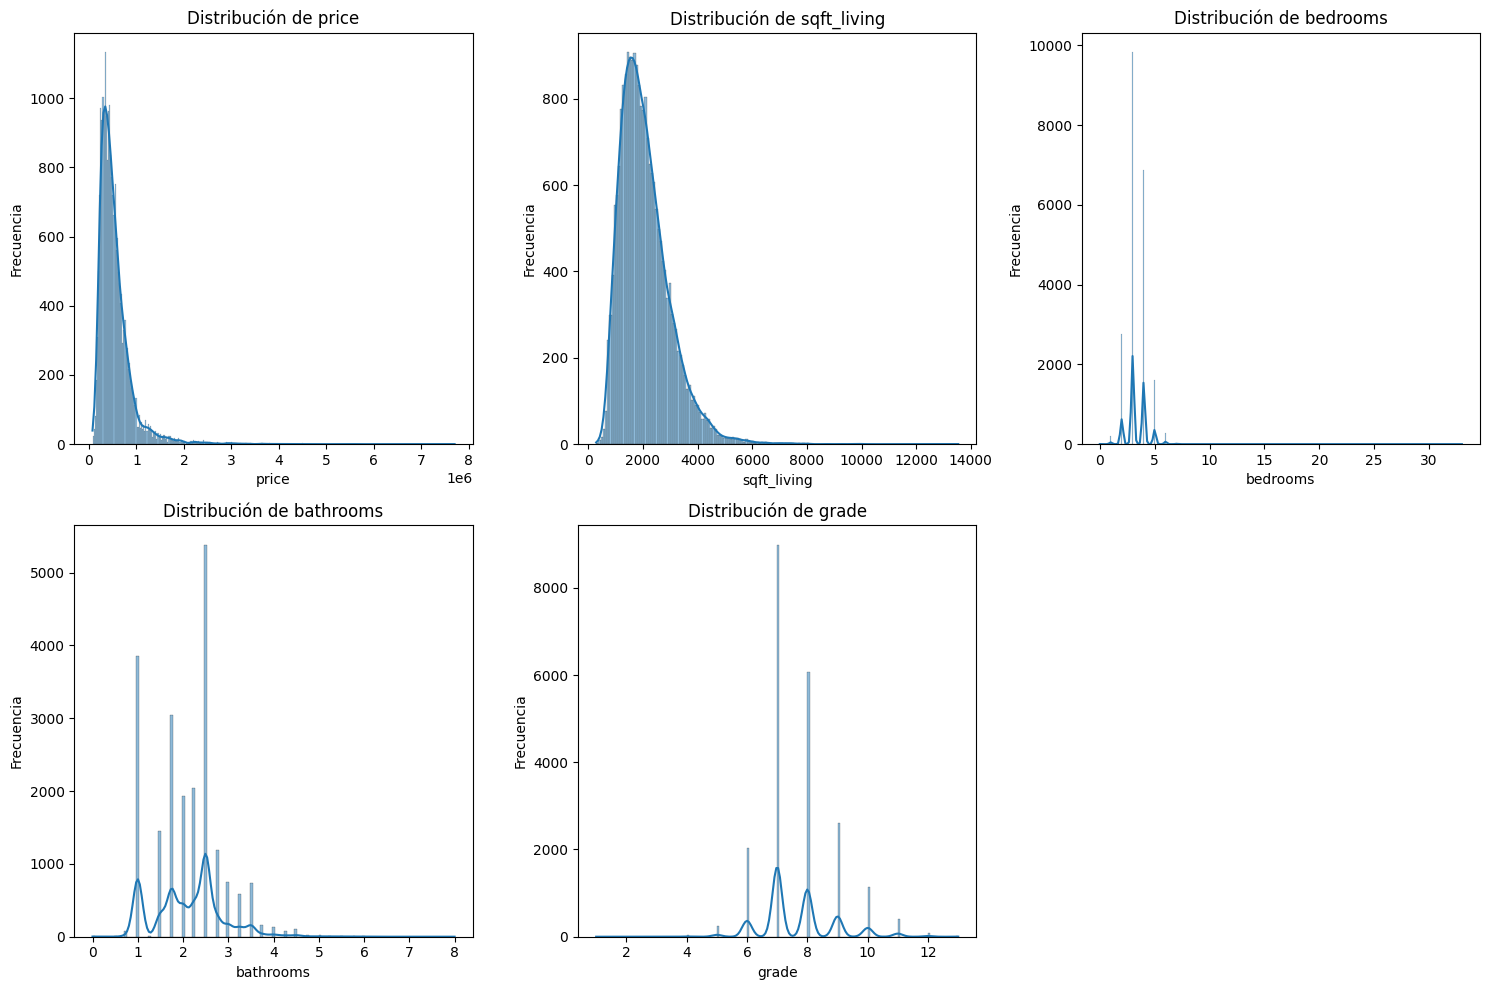

In [17]:
# Histograma de variables numéricas clave
# Seleccionamos algunas para mostrar la distribución
hist_cols = ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'grade']

plt.figure(figsize=(15, 10))
for i, col in enumerate(hist_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Gráficos de Barras para Frecuencia de Variables Categóricas

/tmp/ipykernel_893/3725739726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_893/3725739726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_893/3725739726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipykernel_893/3725739726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the 

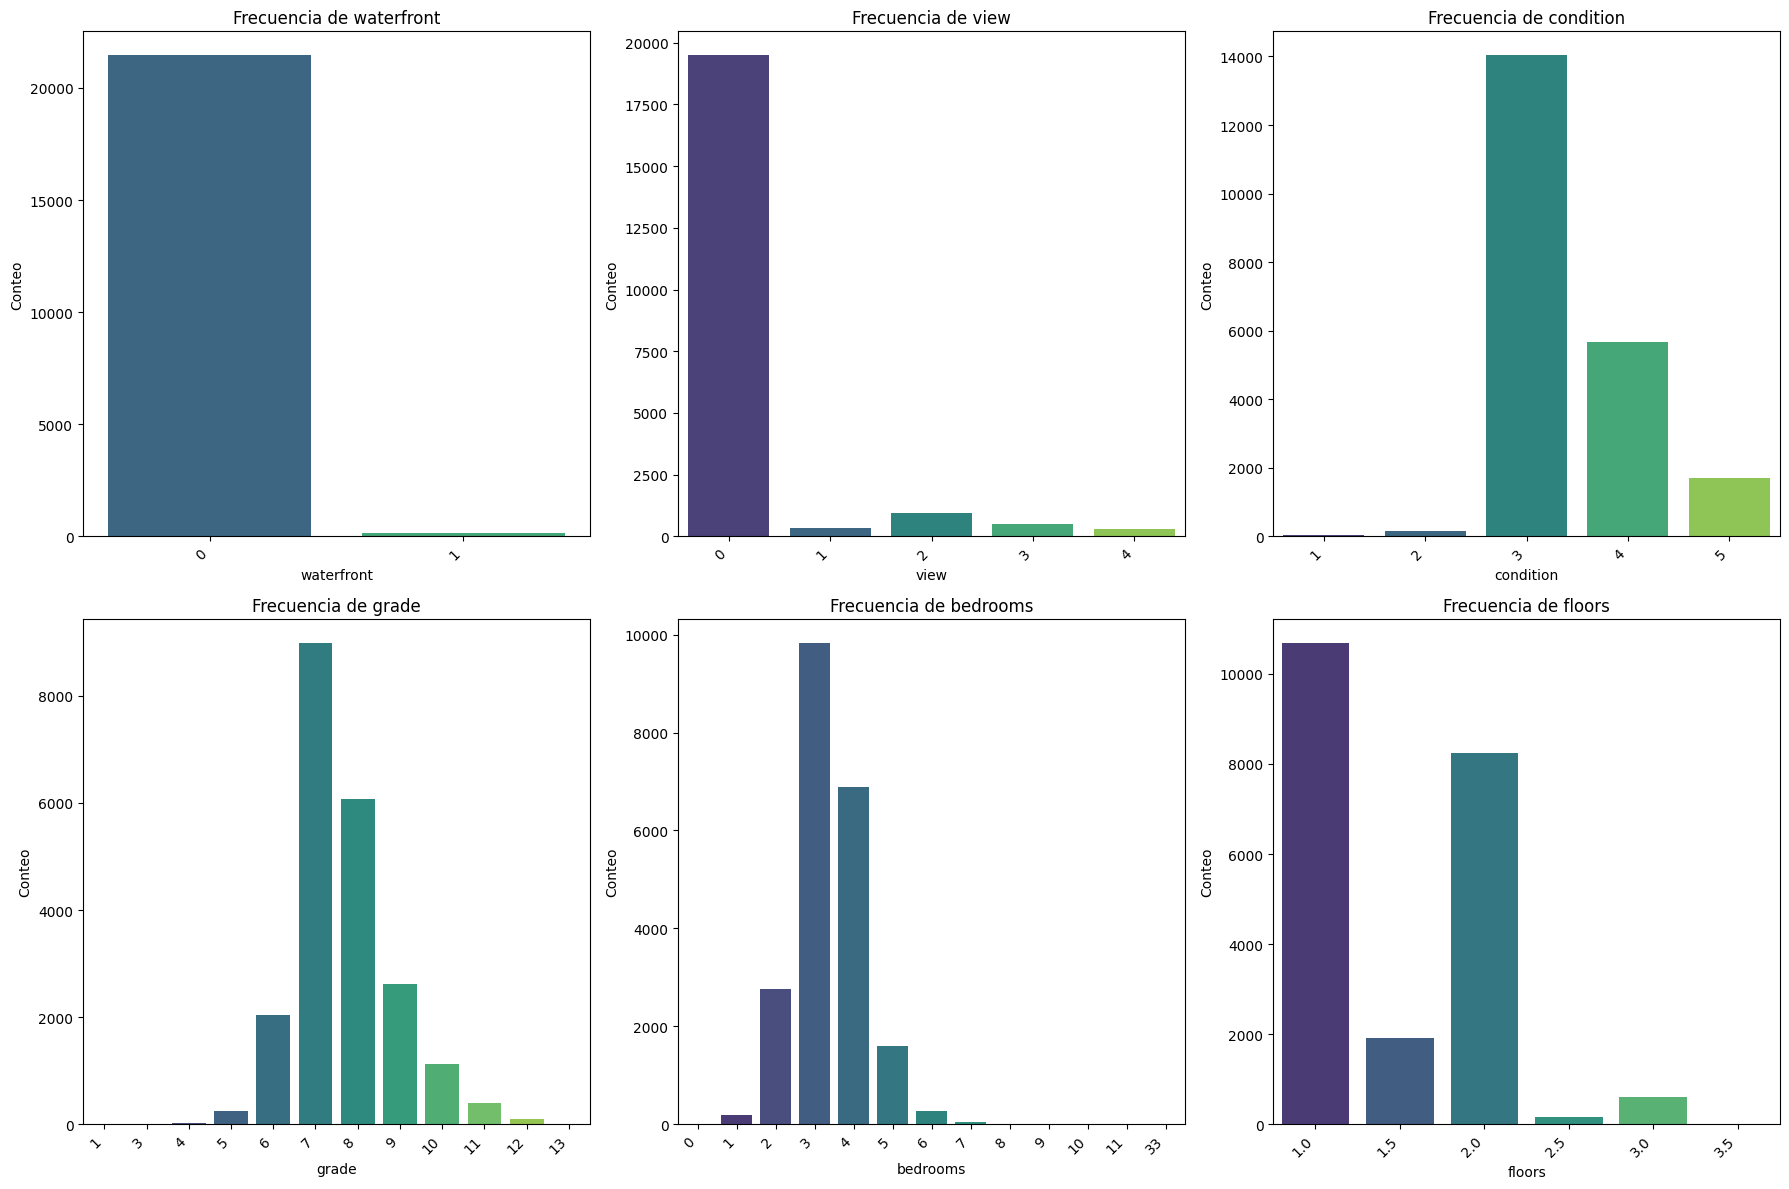

In [18]:
# Gráfico de barras para variables categóricas (o pseudo-categóricas)
bar_cols = ['waterfront', 'view', 'condition', 'grade', 'bedrooms', 'floors']

plt.figure(figsize=(18, 12))
for i, col in enumerate(bar_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Frecuencia de {col}')
    plt.xlabel(col)
    plt.ylabel('Conteo')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()